# 📊 Advanced Exploratory Data Analysis
### Role 2 — Data Analyst: Exploration & Insights

This notebook implements advanced, highly-styled visualizations to identify deep temporal trends, purchasing patterns, and stockout risks. We adhere to the existing dark aesthetic while introducing new chart typologies.

**Data Sources:**
- `data/processed/daily_sales.csv`
- `data/processed/weekly_sales.csv`

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor':   '#0e1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'text.color':       '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.alpha':       0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.dpi':       120,
}) 

PALETTE = ['#58a6ff', '#f0883e', '#3fb950', '#bc8cff', '#f778ba',
           '#79c0ff', '#d29922', '#56d4dd', '#ff7b72', '#7ee787']

PLOTS_DIR = os.path.join('..', 'results', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

def save(fig, name):
    fig.savefig(os.path.join(PLOTS_DIR, name), bbox_inches='tight', dpi=150, facecolor=fig.get_facecolor())

print('✅ Styling loaded')

✅ Styling loaded


In [9]:
df_daily = pd.read_csv('../data/processed/daily_sales.csv', parse_dates=['date'])
df_weekly = pd.read_csv('../data/processed/weekly_sales.csv')

print(f'Daily  : {df_daily.shape[0]:>10,} rows  ×  {df_daily.shape[1]} cols')
print(f'Weekly : {df_weekly.shape[0]:>10,} rows  ×  {df_weekly.shape[1]} cols')

Daily  :    913,000 rows  ×  5 cols
Weekly :    131,000 rows  ×  6 cols


---
## 1. Purchasing Heatmap (Daily Sales Intensity)
Visualizing sales intensity over the last available year to instantly spot holidays, hot-spots, or dead periods.

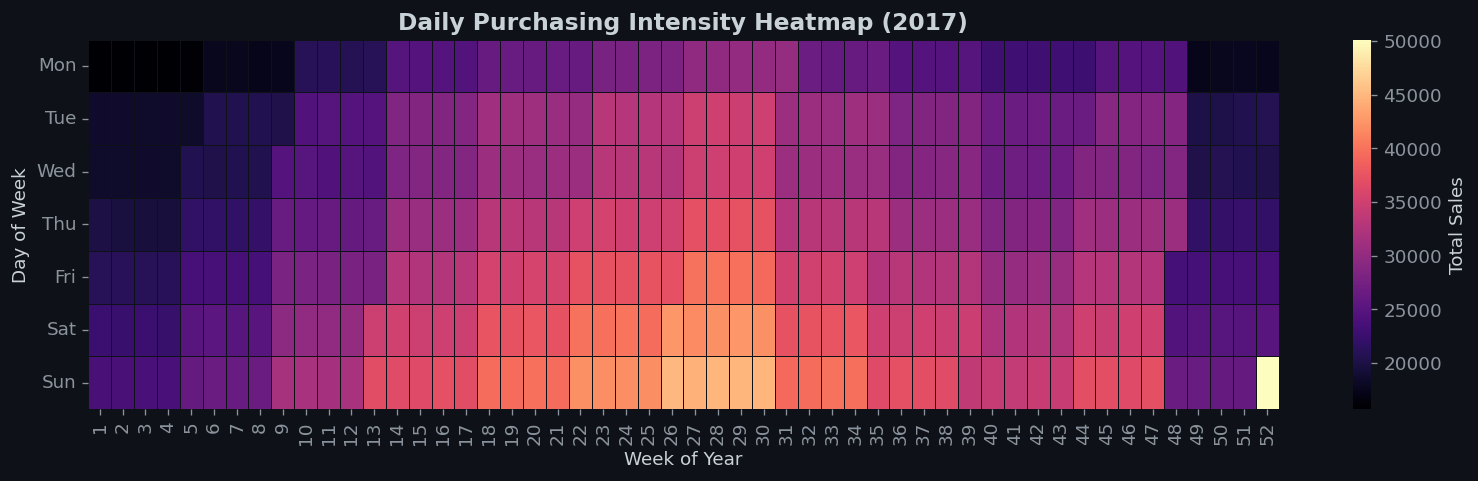

In [10]:
df_daily['year'] = df_daily['date'].dt.year
df_daily['month'] = df_daily['date'].dt.month
df_daily['day_of_year'] = df_daily['date'].dt.dayofyear

last_year = df_daily['year'].max()
df_heat = df_daily[df_daily['year'] == last_year].groupby('date')['sales'].sum().reset_index()
df_heat['week'] = df_heat['date'].dt.isocalendar().week
df_heat['day_of_week'] = df_heat['date'].dt.dayofweek

pivot = df_heat.pivot_table(index='day_of_week', columns='week', values='sales', aggfunc='sum')

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot, cmap='magma', ax=ax, cbar_kws={'label': 'Total Sales'}, linewidths=0.5, linecolor='#0e1117')
ax.set_yticks(np.arange(7) + 0.5)
ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0, color='#8b949e')
ax.set(title=f'Daily Purchasing Intensity Heatmap ({last_year})', xlabel='Week of Year', ylabel='Day of Week')
save(fig, 'adv_1_purchasing_heatmap.png')
plt.show()

---
## 2. Demand Seasonality Polar Chart
Visualizing cyclical nature of sales patterns across months using a styled radar/polar layout.

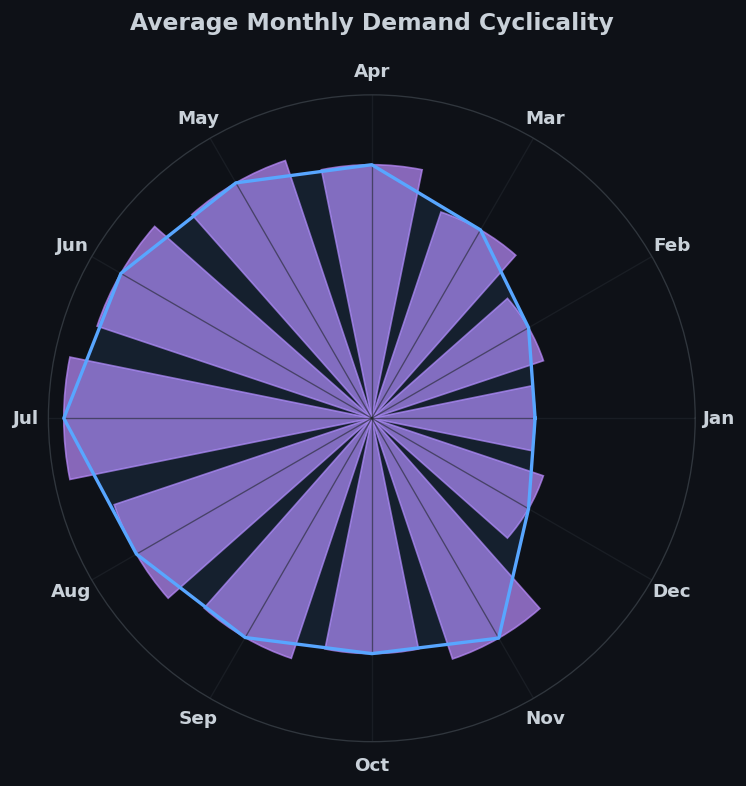

In [11]:
monthly_sales = df_daily.groupby('month')['sales'].mean().reset_index()

theta = np.linspace(0.0, 2 * np.pi, 12, endpoint=False)
radii = monthly_sales['sales'].values

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
ax.set_facecolor('#0e1117')
fig.patch.set_facecolor('#0e1117')

bars = ax.bar(theta, radii, width=0.4, bottom=0.0, color=PALETTE[3], alpha=0.7, edgecolor=PALETTE[3])
ax.plot(np.append(theta, theta[0]), np.append(radii, radii[0]), color=PALETTE[0], linewidth=2)
ax.fill(np.append(theta, theta[0]), np.append(radii, radii[0]), color=PALETTE[0], alpha=0.1)

ax.set_xticks(theta)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], color='#c9d1d9', weight='bold')
ax.set_yticks([])
ax.set_title('Average Monthly Demand Cyclicality', color='#c9d1d9', pad=20, weight='bold')

save(fig, 'adv_2_seasonality_polar.png')
plt.show()

---
## 3. Stockout Risk & Zero-Demand Analysis
Analyzing products that experience days with absolutely zero sales, which could indicate stockouts or severe drops in demand. This directly assists in inventory optimization.

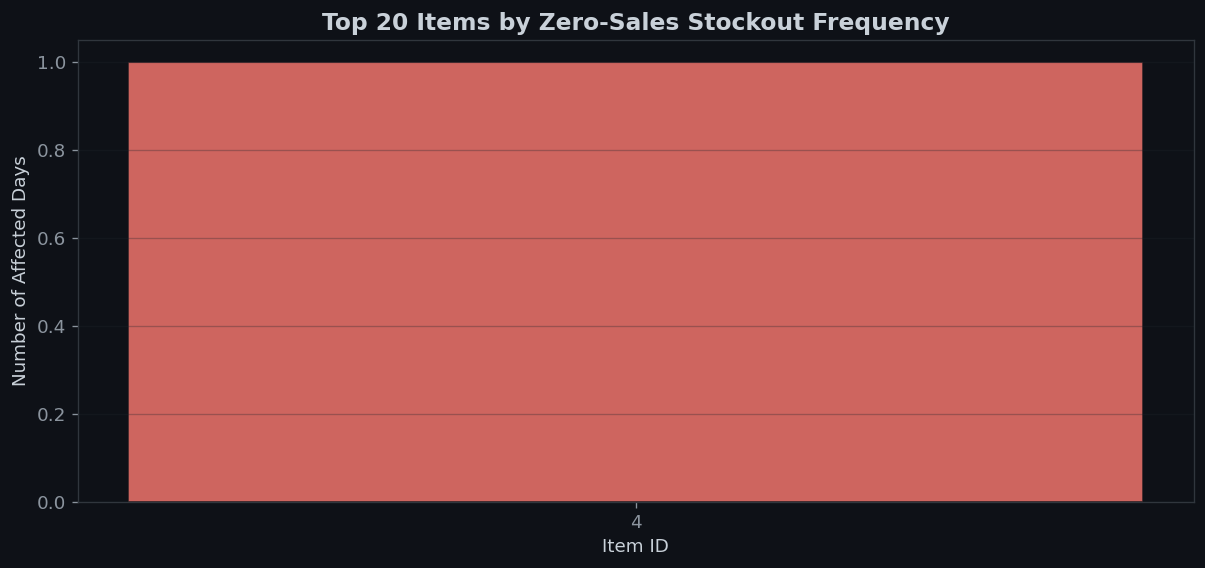

In [12]:
# Count days with exactly 0 sales per item
zero_sales = df_daily[df_daily['sales'] == 0]
zero_counts = zero_sales.groupby('item').size().reset_index(name='zero_days')

if zero_counts.empty:
    threshold = df_daily['sales'].quantile(0.01)
    print(f"No days with exactly 0 sales found. Analyzing lowest 1% demand days (sales <= {threshold:.1f}) as stockout proxies.")
    zero_sales = df_daily[df_daily['sales'] <= threshold]
    zero_counts = zero_sales.groupby('item').size().reset_index(name='low_sales_days')
    col_name = 'low_sales_days'
    title_prefix = 'Lowest Demand Proxy'
else:
    col_name = 'zero_days'
    title_prefix = 'Zero-Sales Stockout'

top_stockouts = zero_counts.sort_values(col_name, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_stockouts['item'].astype(str), top_stockouts[col_name], color=PALETTE[8], alpha=0.8, edgecolor='#0e1117', linewidth=1)
ax.set(title=f'Top 20 Items by {title_prefix} Frequency', xlabel='Item ID', ylabel='Number of Affected Days')
ax.grid(axis='y', alpha=0.3)
save(fig, 'adv_3_stockout_risk_bar.png')
plt.show()

### Stockout Temporal Distribution
Let's see when these stockouts/zero-sales events are happening over the year to identify if they cluster around certain seasons or holidays.

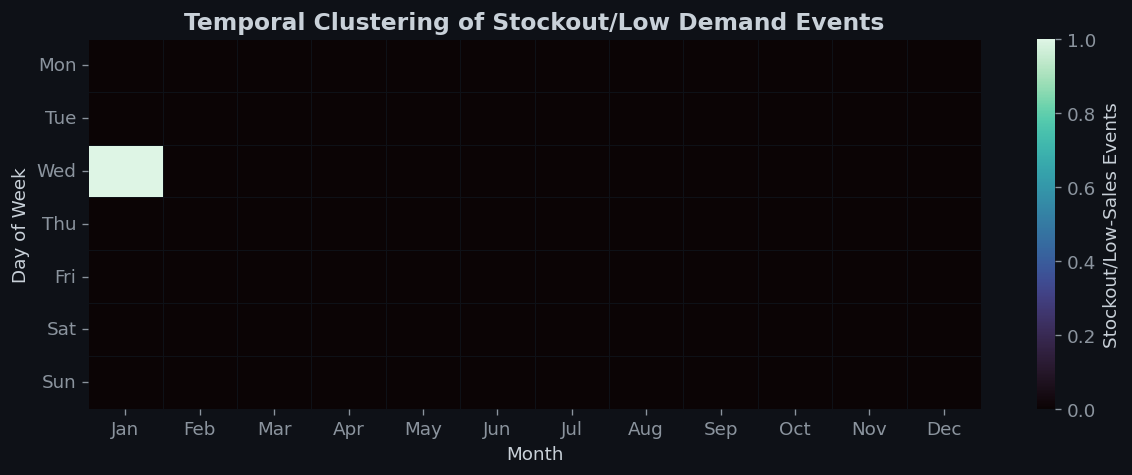

In [13]:
if 'day_of_week' not in zero_sales.columns:
    zero_sales['month'] = zero_sales['date'].dt.month
    zero_sales['day_of_week'] = zero_sales['date'].dt.dayofweek

# Aggregate zero/low sales events by Month and Day of Week
stockout_heatmap_data = zero_sales.groupby(['month', 'day_of_week']).size().reset_index(name='stockout_events')
stockout_pivot = stockout_heatmap_data.pivot(index='day_of_week', columns='month', values='stockout_events').fillna(0)
stockout_pivot = stockout_pivot.reindex(index=range(7), columns=range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(stockout_pivot, cmap='mako', ax=ax, cbar_kws={'label': 'Stockout/Low-Sales Events'}, linewidths=0.5, linecolor='#0e1117')
ax.set_yticks(np.arange(7) + 0.5)
ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0, color='#8b949e')
ax.set_xticks(np.arange(12) + 0.5)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], color='#8b949e')
ax.set(title='Temporal Clustering of Stockout/Low Demand Events', xlabel='Month', ylabel='Day of Week')
save(fig, 'adv_4_stockout_temporal_heatmap.png')
plt.show()

---
## 4. Volatility / Dumbbell Plot
Comparing Minimum vs Maximum weekly sales per item to highlight volatility per product. Wide gaps indicate highly volatile items that are harder to forecast.

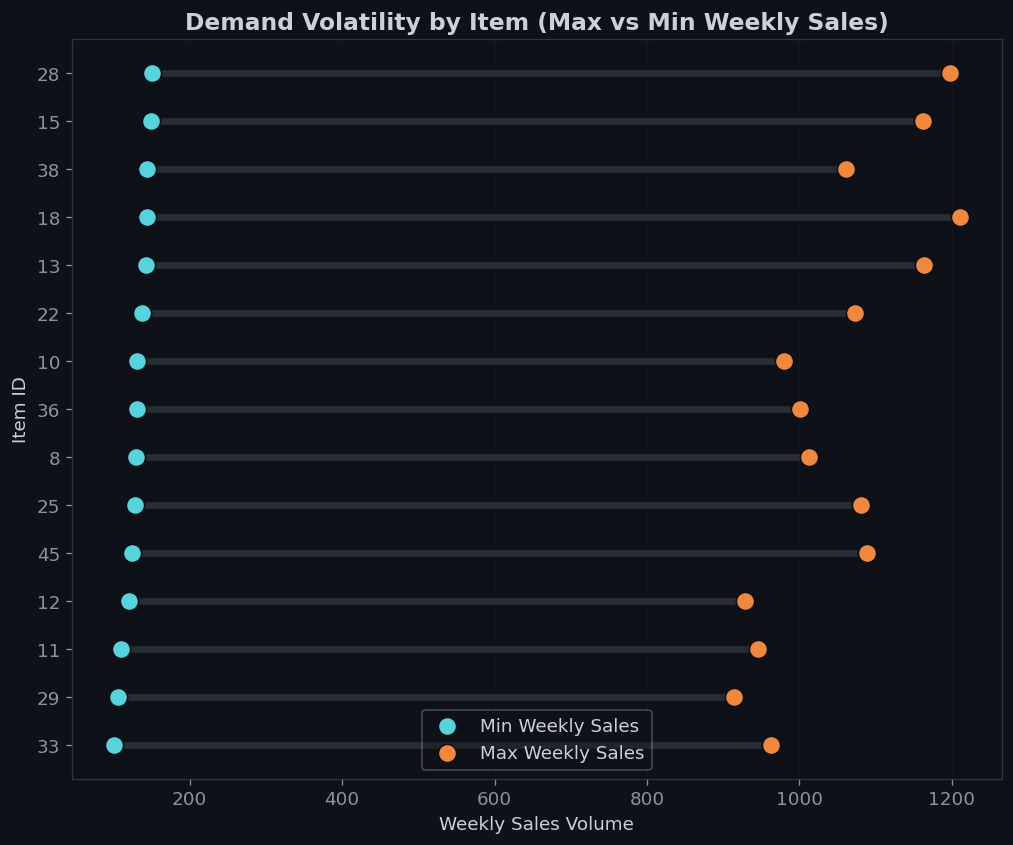

In [14]:
item_volatility = df_weekly.groupby('item')['weekly_sales'].agg(['min', 'max']).reset_index()
item_volatility['diff'] = item_volatility['max'] - item_volatility['min']

# Take top 15 most volatile items (by max-min difference)
top_vola = item_volatility.sort_values('diff', ascending=False).head(15).sort_values('min')

fig, ax = plt.subplots(figsize=(10, 8))

ax.hlines(y=top_vola['item'].astype(str), xmin=top_vola['min'], xmax=top_vola['max'], color='#30363d', alpha=0.8, linewidth=4)
ax.scatter(top_vola['min'], top_vola['item'].astype(str), color=PALETTE[7], s=120, label='Min Weekly Sales', zorder=3, edgecolor='#0e1117')
ax.scatter(top_vola['max'], top_vola['item'].astype(str), color=PALETTE[1], s=120, label='Max Weekly Sales', zorder=3, edgecolor='#0e1117')

ax.set(title='Demand Volatility by Item (Max vs Min Weekly Sales)', xlabel='Weekly Sales Volume', ylabel='Item ID')
ax.legend(framealpha=0.3)
ax.grid(axis='x', alpha=0.3)
save(fig, 'adv_5_volatility_dumbbell.png')
plt.show()